In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import category_encoders as ce

adult = pd.read_csv('adult.csv')
adult = adult.replace('?', np.nan)
adult['income'] = adult['income'].apply(lambda x: 1 if x == '>50K' else 0)
adult['gender'] = adult['gender'].apply(lambda x: 1 if x == 'Male' else 0)

print(adult.shape)
adult.head()

(48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,0,0,0,30,United-States,0


In [6]:
train_idx, test_idx = train_test_split(
    adult.index,
    test_size=0.2,
    stratify=adult['income'],
    random_state=42
)
print('Train:', len(train_idx), '  Test:', len(test_idx))
print('Income rate (train):', adult.loc[train_idx, 'income'].mean().round(3))

Train: 39073   Test: 9769
Income rate (train): 0.239


### Feature engineering

In [7]:
def engineer_features(df, occ_encoder=None, fit_encoder=False):
    d = df.copy()

    # grouped categories: married vs not
    d['is_married'] = d['marital-status'].isin(
        ['Married-civ-spouse', 'Married-AF-spouse']
    ).astype(int)

    # transformation: net capital + binary flag
    d['capital_net'] = d['capital-gain'] - d['capital-loss']
    d['has_capital'] = (d['capital_net'] != 0).astype(int)

    # interaction: age x education (hereditary principle)
    d['age_x_edu'] = d['age'] * d['educational-num']

    # binning: hours into work intensity groups
    d['hours_bucket'] = pd.cut(
        d['hours-per-week'],
        bins=[0, 34, 40, 50, 99],
        labels=['part_time', 'standard', 'overtime', 'heavy']
    ).astype(str)

    # grouped categories: US vs not
    d['is_us_native'] = (d['native-country'] == 'United-States').astype(int)

    # target encoding for occupation — fit on train only
    if fit_encoder:
        occ_encoder = ce.TargetEncoder(cols=['occupation'], smoothing=10)
        occ_encoder.fit(d[['occupation']], d['income'])
    d['occ_income_rate'] = occ_encoder.transform(d[['occupation']])['occupation']

    return d, occ_encoder


train_df_raw = adult.loc[train_idx].copy()
test_df_raw  = adult.loc[test_idx].copy()

train_df, enc = engineer_features(train_df_raw, fit_encoder=True)
test_df,  _   = engineer_features(test_df_raw, occ_encoder=enc, fit_encoder=False)

new_cols = [c for c in train_df.columns if c not in adult.columns]
print('New features:', new_cols)
train_df[new_cols].head()

New features: ['is_married', 'capital_net', 'has_capital', 'age_x_edu', 'hours_bucket', 'is_us_native', 'occ_income_rate']


,is_married,capital_net,has_capital,age_x_edu,hours_bucket,is_us_native,occ_income_rate
34342,0,0,0,639,part_time,1,0.062987
18559,0,0,0,102,part_time,1,0.262896
12477,1,0,0,243,standard,0,0.039980
560,0,0,0,387,standard,1,0.141237
3427,1,0,0,403,standard,1,0.481716


### Prepare feature matrices


In [8]:
DROP = ['income', 'fnlwgt', 'education',
        'marital-status', 'native-country',
        'capital-gain', 'capital-loss']

CAT_COLS = ['workclass', 'occupation', 'relationship', 'race', 'hours_bucket']

# XGBoost — keep categoricals as category dtype
def prep_xgb(df):
    d = df.drop(columns=DROP, errors='ignore')
    for c in CAT_COLS:
        if c in d.columns:
            d[c] = d[c].astype('category')
    return d

X_train_xgb = prep_xgb(train_df)
X_test_xgb  = prep_xgb(test_df)
y_train = train_df['income']
y_test  = test_df['income']

# Logistic regression — fully numeric, one-hot encode
def prep_lr(df):
    d = df.drop(columns=DROP + ['occupation'], errors='ignore')
    d = pd.get_dummies(d, columns=['workclass', 'relationship', 'race', 'hours_bucket'],
                       drop_first=True)
    return d

X_train_lr = prep_lr(train_df)
X_test_lr  = prep_lr(test_df)
X_test_lr  = X_test_lr.reindex(columns=X_train_lr.columns, fill_value=0)

print('XGB features:', X_train_xgb.shape[1])
print('LR  features:', X_train_lr.shape[1])

XGB features: 15
LR  features: 29


### Model 1: XGBoost (tuned)

In [9]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Class ratio (neg/pos): {pos_weight:.2f}')

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    enable_categorical=True,
    eval_metric='logloss',
    random_state=42
)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_cv = cross_val_score(xgb, X_train_xgb, y_train, cv=kf, scoring='roc_auc')
print(f'XGB CV ROC-AUC: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}')

xgb.fit(X_train_xgb, y_train)
xgb_prob = xgb.predict_proba(X_test_xgb)[:, 1]
xgb_pred = (xgb_prob >= 0.5).astype(int)

print(f'\nXGB Test Accuracy : {accuracy_score(y_test, xgb_pred):.4f}')
print(f'XGB Test ROC-AUC  : {roc_auc_score(y_test, xgb_prob):.4f}')
print()
print(classification_report(y_test, xgb_pred))

Class ratio (neg/pos): 3.18
XGB CV ROC-AUC: 0.9282 ± 0.0031

XGB Test Accuracy : 0.8353
XGB Test ROC-AUC  : 0.9303

              precision    recall  f1-score   support

           0       0.95      0.83      0.88      7431
           1       0.61      0.86      0.71      2338

    accuracy                           0.84      9769
   macro avg       0.78      0.84      0.80      9769
weighted avg       0.87      0.84      0.84      9769



### XGBoost feature importance


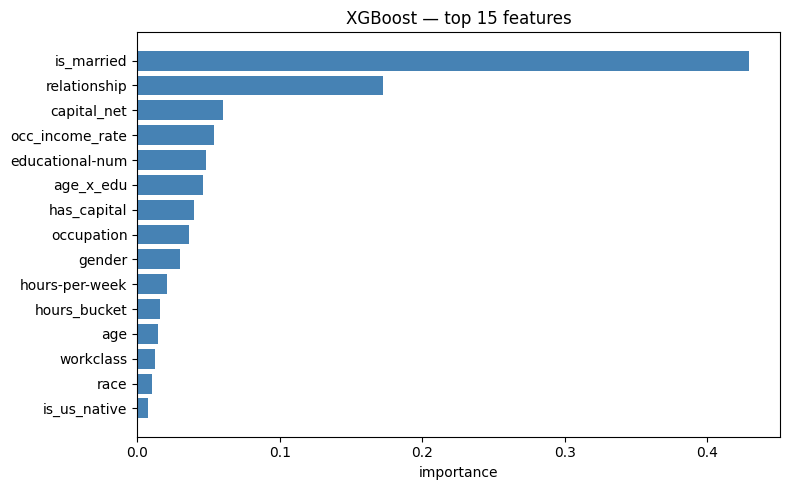

        feature  importance
     is_married    0.429535
   relationship    0.172630
    capital_net    0.059942
occ_income_rate    0.054199
educational-num    0.048080
      age_x_edu    0.046151
    has_capital    0.039996
     occupation    0.036718
         gender    0.030434
 hours-per-week    0.021108
   hours_bucket    0.015919
            age    0.014480
      workclass    0.012369
           race    0.010485
   is_us_native    0.007955


In [10]:
imp_df = pd.DataFrame({
    'feature': X_train_xgb.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df['feature'].head(15)[::-1], imp_df['importance'].head(15)[::-1], color='steelblue')
ax.set_title('XGBoost — top 15 features')
ax.set_xlabel('importance')
plt.tight_layout()
plt.show()

print(imp_df.head(15).to_string(index=False))

### Model 2: Logistic Regression (tuned)


In [11]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        C=0.1,
        class_weight='balanced',
        max_iter=1000,
        solver='lbfgs',
        random_state=42
    ))
])

lr_cv = cross_val_score(lr_pipe, X_train_lr, y_train, cv=kf, scoring='roc_auc')
print(f'LR CV ROC-AUC: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}')

lr_pipe.fit(X_train_lr, y_train)
lr_prob = lr_pipe.predict_proba(X_test_lr)[:, 1]
lr_pred = (lr_prob >= 0.5).astype(int)

print(f'\nLR Test Accuracy : {accuracy_score(y_test, lr_pred):.4f}')
print(f'LR Test ROC-AUC  : {roc_auc_score(y_test, lr_prob):.4f}')
print()
print(classification_report(y_test, lr_pred))

LR CV ROC-AUC: 0.9028 ± 0.0040

LR Test Accuracy : 0.8059
LR Test ROC-AUC  : 0.9026

              precision    recall  f1-score   support

           0       0.94      0.79      0.86      7431
           1       0.56      0.84      0.68      2338

    accuracy                           0.81      9769
   macro avg       0.75      0.82      0.77      9769
weighted avg       0.85      0.81      0.82      9769



### LR coefficients

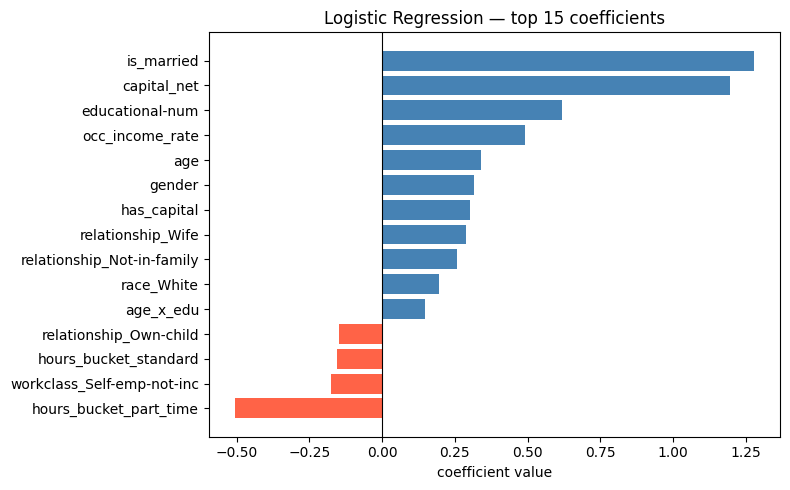

                   feature      coef
                is_married  1.278103
               capital_net  1.195573
           educational-num  0.616661
    hours_bucket_part_time -0.506904
           occ_income_rate  0.489388
                       age  0.339732
                    gender  0.316332
               has_capital  0.303102
         relationship_Wife  0.289313
relationship_Not-in-family  0.255849
                race_White  0.196496
workclass_Self-emp-not-inc -0.176647
     hours_bucket_standard -0.155219
    relationship_Own-child -0.149615
                 age_x_edu  0.145829


In [12]:
coef_df = pd.DataFrame({
    'feature': X_train_lr.columns,
    'coef': lr_pipe.named_steps['lr'].coef_[0]
})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

top = coef_df.head(15).sort_values('coef')
colors = ['steelblue' if c > 0 else 'tomato' for c in top['coef']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top['feature'], top['coef'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — top 15 coefficients')
ax.set_xlabel('coefficient value')
plt.tight_layout()
plt.show()

print(coef_df.head(15)[['feature', 'coef']].to_string(index=False))

### Ensemble — probability averaging
Trying both equal weights and a weighted version that leans on XGBoost more (since it's the stronger model here).

In [13]:
# equal weights
ens_prob_eq   = 0.5 * xgb_prob + 0.5 * lr_prob
ens_pred_eq   = (ens_prob_eq >= 0.5).astype(int)

# weighted — lean on XGBoost
ens_prob_wt   = 0.65 * xgb_prob + 0.35 * lr_prob
ens_pred_wt   = (ens_prob_wt >= 0.5).astype(int)

results = {
    'XGBoost':            (accuracy_score(y_test, xgb_pred),    roc_auc_score(y_test, xgb_prob)),
    'Logistic Reg':       (accuracy_score(y_test, lr_pred),      roc_auc_score(y_test, lr_prob)),
    'Ensemble (equal)':   (accuracy_score(y_test, ens_pred_eq),  roc_auc_score(y_test, ens_prob_eq)),
    'Ensemble (65/35)':   (accuracy_score(y_test, ens_pred_wt),  roc_auc_score(y_test, ens_prob_wt)),
}

print(f'{"Model":<22} {"Accuracy":>10} {"ROC-AUC":>10}')
print('-' * 44)
for name, (acc, auc) in results.items():
    print(f'{name:<22} {acc:>10.4f} {auc:>10.4f}')

Model                    Accuracy    ROC-AUC
--------------------------------------------
XGBoost                    0.8353     0.9303
Logistic Reg               0.8059     0.9026
Ensemble (equal)           0.8300     0.9243
Ensemble (65/35)           0.8352     0.9273


### Reflection

The feature that stood out the most was is_married. The original column had a bunch of categories, but once I simplified it to married vs not, it became way more useful. occ_income_rate was also important, especially for XGBoost, since it turned occupation into something the model could actually use without adding a ton of noise. 
XGBoost performed the best overall. It handled the data better, especially since there are a lot of interactions going on

The ensemble helped a little, but nothing major. There was a small bump in ROC-AUC, but accuracy stayed about the same. It seems like logistic regression added a bit, but XGBoost was already doing most of the work.

The models definitely reacted differently to the features. Logistic regression benefited more from the simpler, binary features since it can’t really pick up on interactions by itself. XGBoost was able to get more out of the more complex features.

Overall, this felt like a good process to follow. Start with a basic model, add features, see what actually helps, then tune from there. Next step would probably be to look at where the model is messing up and try to fix that with better features.